In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

import umap

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers

from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

import numpy as np


from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import *


rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

(1797, 64)


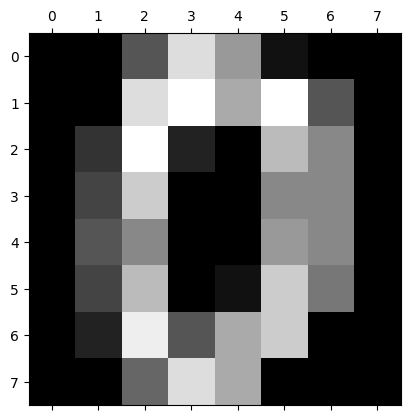

In [2]:
mnist = fetch_openml("mnist_784")
mnist_data = np.array(mnist.data) / 255.0
mnist_targets = np.array(mnist.target).astype(int)
digits = load_digits()
print(digits.data.shape)

plt.matshow(digits.images[0], cmap="gray")
plt.show()

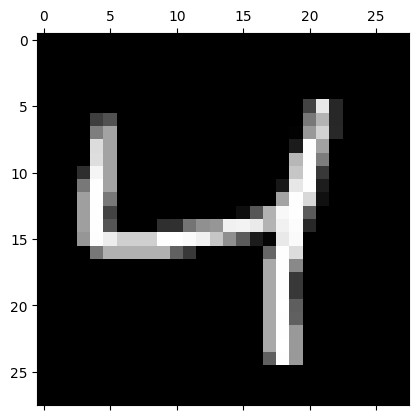

In [3]:
plt.matshow(mnist_data[2].reshape(28, 28), cmap="gray")
plt.show()

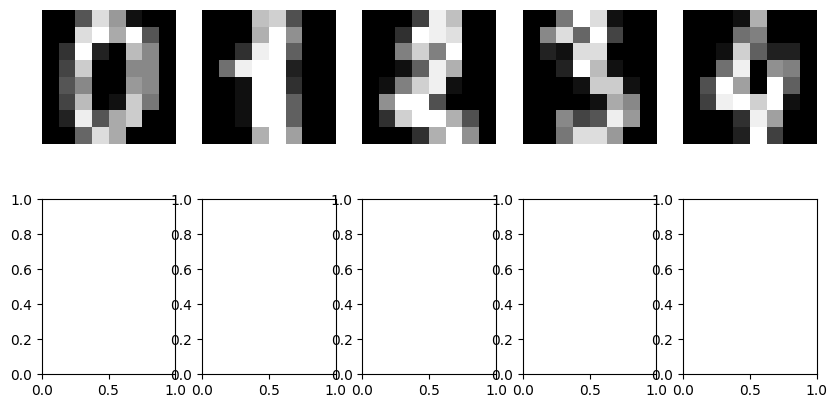

In [4]:
def plot_images(imgs, shape=(28, 28)):
    assert len(imgs) <= 10, "Can only plot up to 10 images"
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, img in enumerate(imgs):
        axes[i//5, i%5].imshow(img.reshape(*shape), cmap="gray")
        axes[i//5, i%5].axis("off")
    plt.show()

plot_images(digits.data[:5], shape=(8, 8))

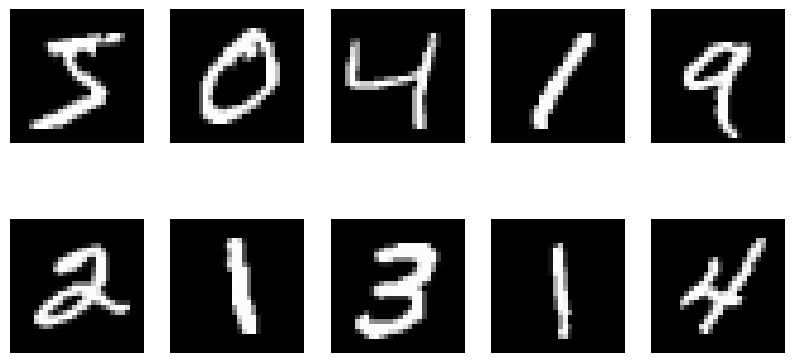

In [5]:
plot_images(mnist_data[:10], shape=(28, 28))

In [6]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )




def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
        stax.Sigmoid,
    )



def mean_network(hidden_dim, m_dim):
    SafeSoftplus = stax.elementwise(lambda x: jnp.log(1 + jnp.exp(x - 3.0)) + 1e-5)
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(m_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(m_dim, W_init=stax.randn()), SafeSoftplus),
        ),
    )



In [7]:
rng_key, s1, s2, s3 = jax.random.split(rng_key, 4)

diff = mnist_data.max() - mnist_data.min()
mnist_data = (mnist_data - mnist_data.min()) / diff if mnist_data.max() != mnist_data.min() else mnist_data

X, X_test, y, y_test = sklearn.model_selection.train_test_split(mnist_data, mnist_targets, test_size=0.2, random_state=42)

#dequantize the data from 16 colors (1-16) to numbers between 0 and 1. Adding noise:

X = jnp.clip(X + 0.05 * jax.random.normal(s1, X.shape), 0, 1)

#Then binarize
X = jax.random.bernoulli(s2, X)
#X = (X > 0.5).astype(float)


# No noise for test set, just binarize it:
X_test = jax.random.bernoulli(s3, X_test)
#X_test = (X_test > 0.5).astype(float)

#Make 1 if above 0.5, 0 otherwise:
#X = (X > 0.5).astype(float)



batch_size = 128

dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]




out_dim = X.shape[1]
hidden_dim = 128
z_dim = 16



lr=5e-4
adam = optim.Adam(lr)


encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}


In [8]:
rng_key, sub_key = jax.random.split(rng_key)
base_vae = BaseVAE(encoder, encoder_args, decoder, decoder_args, z_dim, model_mode="b")

base_vae.train(dataloader, X.shape[0], adam, 15, sub_key, annealing_epochs=0)




100%|██████████| 15/15 [00:13<00:00,  1.09it/s]


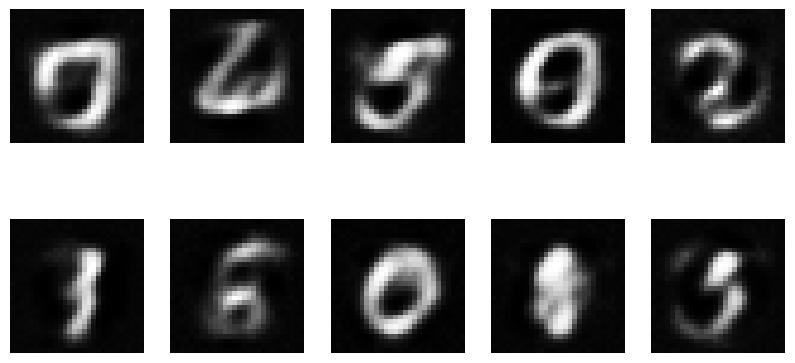

In [9]:
rng_key, sub_key = jax.random.split(rng_key)
plot_images(base_vae.sample(sub_key, 10)["x"], shape=(28, 28))

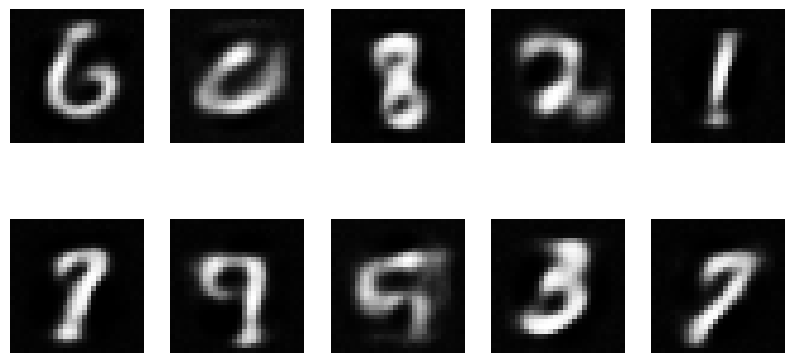

In [10]:
rng_key, sub_key = jax.random.split(rng_key)
X_test_sample = X_test[np.random.choice(X_test.shape[0], 10, replace=False)]
encoded = base_vae.encode_batch(X_test_sample, sub_key)
reconstructed = base_vae.decode_latent({"z": encoded["z"]}, sub_key)["x"]
plot_images(reconstructed, shape=(28, 28))

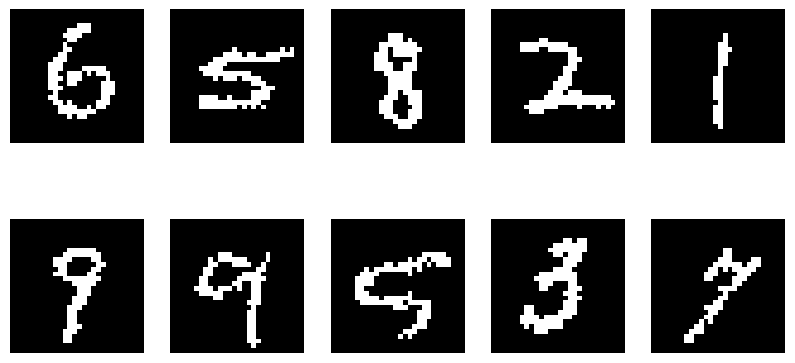

In [11]:
plot_images(X_test_sample, shape=(28, 28))

In [12]:
def plot_aggregate_posterior_umap(vae, D, sub_key, y):
    '''
    y: the labels for the digits
    '''
    
    #Aggregate posterior
    encoded = vae.encode_batch(D, sub_key)
    z = encoded["z"]

    
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(z)
    

    #Samples from prior:
    prior_samples = jax.random.normal(sub_key, (20000, vae.z_dim))
    prior_embedding = reducer.transform(prior_samples)
    plt.scatter(prior_embedding[:, 0], prior_embedding[:, 1], s=5, alpha=1, label="Prior Samples", c="black")


    #loop through each digit and plot in different color:
    for digit in range(10):
        mask = (y == digit)
        plt.scatter(embedding[mask, 0], embedding[mask, 1], s=5, alpha=1, label=f"Digit {digit}", c=plt.cm.tab10(digit))

    plt.title("Aggregate Posterior in Latent Space (UMAP)")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    
    #show legend outside of plot:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    

    plt.show()
    

def plot_aggregate_posterior_pca(vae, D, sub_key):
    
    #Aggregate posterior
    encoded = vae.encode_batch(D, sub_key)
    z = encoded["z"]

    
    pca = PCA(n_components=2)
    embedding = pca.fit_transform(z)

    plt.scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.2, label="Encoded Data")

    #Samples from prior:
    prior_samples = jax.random.normal(sub_key, (10000, vae.z_dim))
    prior_embedding = pca.transform(prior_samples)
    plt.scatter(prior_embedding[:, 0], prior_embedding[:, 1], s=5, alpha=0.2, label="Prior Samples")

    

    plt.title("Aggregate Posterior in Latent Space (PCA)")
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.legend()
    plt.show()

/tmp/ipykernel_1628/1310191040.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(embedding[mask, 0], embedding[mask, 1], s=5, alpha=1, label=f"Digit {digit}", c=plt.cm.tab10(digit))


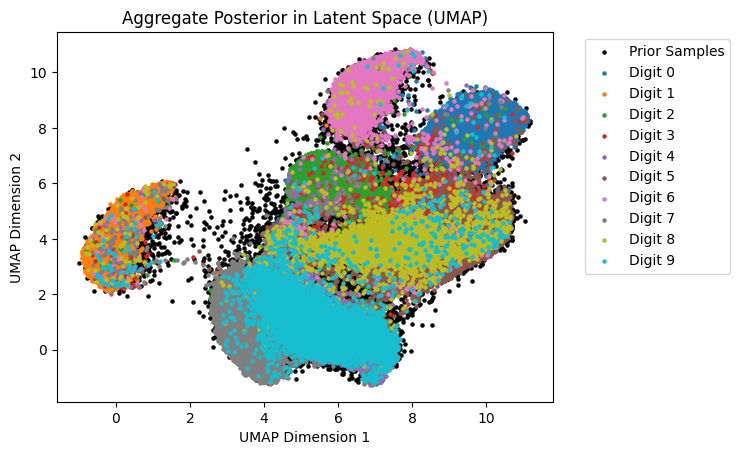

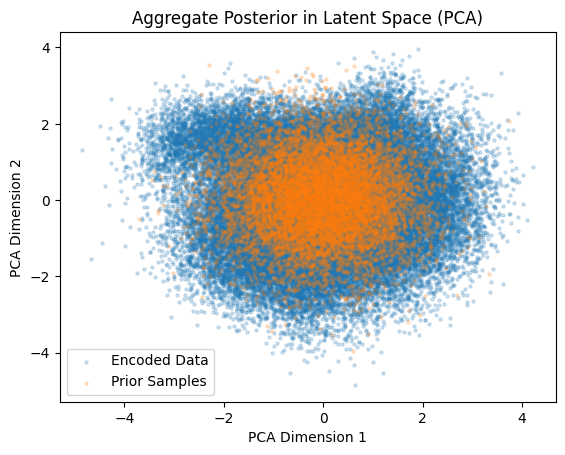

In [13]:
rng_key, sub_key = jax.random.split(rng_key)
plot_aggregate_posterior_umap(base_vae, X, sub_key, y)
plot_aggregate_posterior_pca(base_vae, X, sub_key)

# Test the new architecture


In [14]:
def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(out_dim),
    )

def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(f_dim),
        stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))
    )

def g(z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), a_min=0.0, a_max=20.0) + variance_floor)
    return stax.serial(
        stax.FanOut(2),
        stax.parallel(
            stax.serial(stax.Dense(z_dim), stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        )
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(h_dim),
    )

In [43]:



out_dim = X.shape[1]
hidden_dim =128
z_dim = 50
m_dim = 5
h_dim = 20


lr=5e-3

def lr_scheduler(lr_start=5e-3, decay_rate=0.9, decay_steps=300, floor=1e-5):
    def schedule(step):
        return lr_start * (decay_rate ** (step // decay_steps)) + floor
    return schedule








decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
f_args = {"hidden_dim": z_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim, "variance_floor": 0.05}
h_args = {"hidden_dim": h_dim, "h_dim": z_dim}
flow_args = {"input_dim": m_dim, "hidden_dims": [m_dim], "steps": 0, "inv": True} # 0 means identity transform

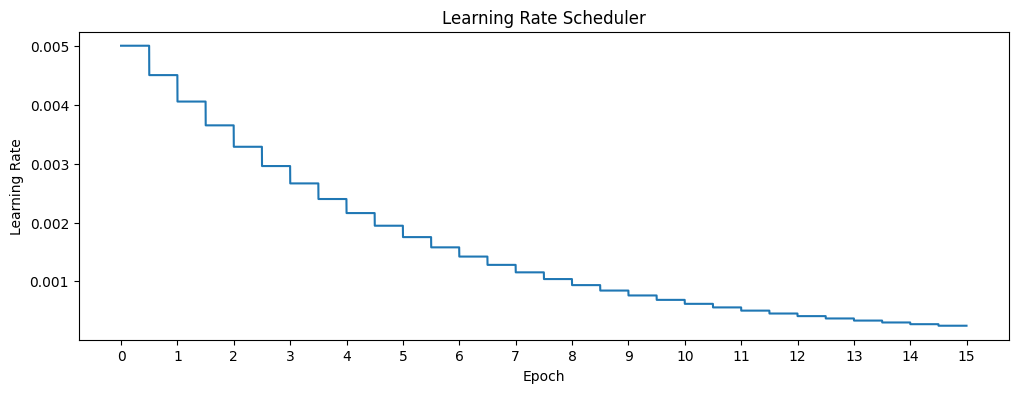

In [45]:

epochs = 15
steps = len(X)/batch_size * epochs
lr_scheduler_fn = lr_scheduler(lr, decay_rate=0.9, decay_steps=steps/30, floor=1e-5)
#plot lr scheduler for 20000 steps
lrs = [lr_scheduler_fn(step) for step in range(int(steps))]
plt.figure(figsize=(12, 4))
plt.plot(lrs)

plt.title("Learning Rate Scheduler")

plt.xticks(np.linspace(0, steps, epochs+1), [f"{i}" for i in range(epochs+1)])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.show()



adam = optim.ClippedAdam(lr_scheduler_fn, clip_norm=10)

In [ ]:
debug = False
jax.config.update("jax_debug_nans", debug)
jax.config.update("jax_disable_jit", False)

rng_key, sub_key = jax.random.split(rng_key)
smivae74 = SMIVAE74(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, 2, z_dim, m_dim, normalizing_flow, flow_args, model_mode="b")

smivae74.train(dataloader, len(X), adam, num_epochs=epochs, rng_key=sub_key, num_stein_particles=25, annealed_sites=["z0", "z1", "z2", "z3", "m"], 
               annealing_epochs=8, bandwidth_scaler=15)

Epoch 14, Loss: 85202.98: 100%|██████████| 15/15 [15:31<00:00, 62.13s/it]


Ran with 6570 batches


In [47]:
#Save the parameters of the model:
import pickle
with open("smivae74_params.pkl", "wb") as f:
    pickle.dump(smivae74.params, f)



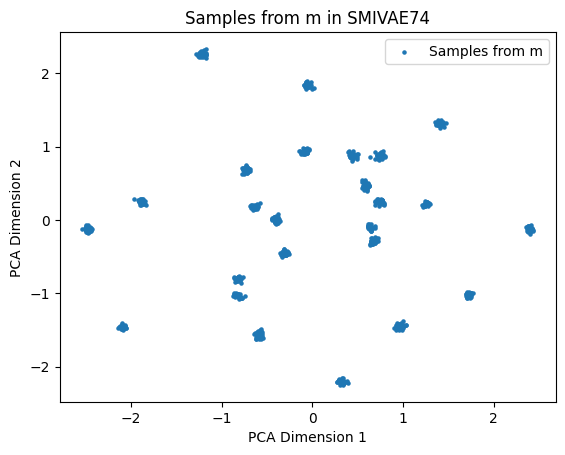

In [48]:
sites=smivae74.sample(sub_key, 1000)
sites

# plot sites["m"] using pca:
pca = PCA(n_components=2)
m_embedding = pca.fit_transform(sites["m"])
plt.scatter(m_embedding[:, 0], m_embedding[:, 1], s=5, alpha=1, label="Samples from m")
plt.title("Samples from m in SMIVAE74")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.show()

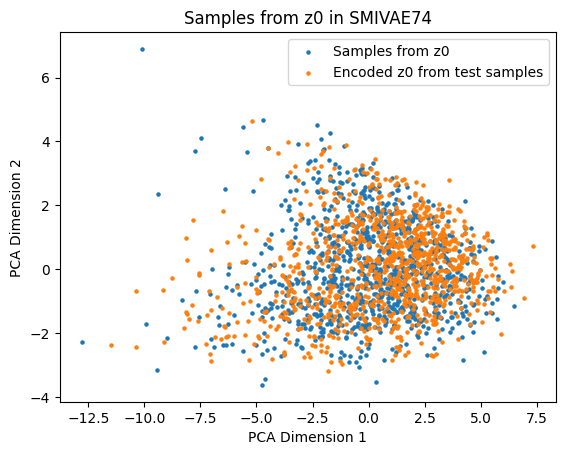

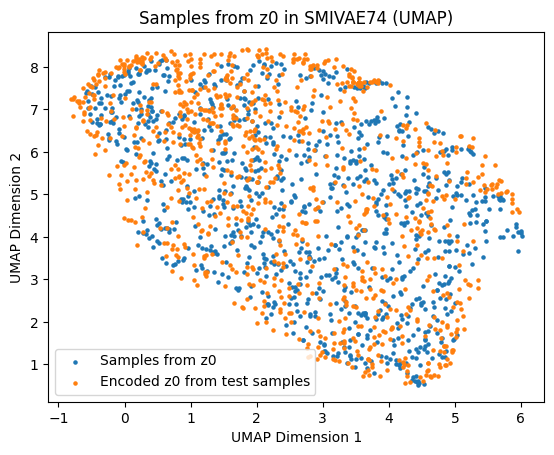

In [56]:
rng_key, sub_key = jax.random.split(rng_key)
X_test_sample = X_test[np.random.choice(X_test.shape[0], 1000, replace=False)]
encoded = smivae74.encode_batch(X_test_sample, sub_key)

z0_embedding = pca.fit_transform(sites["z0"])
z0_embedding_recon = pca.transform(encoded["z0"])
# plot original z0 samples and reconstructions in same plot:
plt.scatter(z0_embedding[:, 0], z0_embedding[:, 1], s=5, alpha=1, label="Samples from z0")
plt.scatter(z0_embedding_recon[:, 0], z0_embedding_recon[:, 1], s=5, alpha=1, label="Encoded z0 from test samples")
plt.title("Samples from z0 in SMIVAE74")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.show()

# Now with UMAP
reducer = umap.UMAP()
z0_embedding_umap = reducer.fit_transform(sites["z0"])
z0_embedding_recon_umap = reducer.transform(encoded["z0"])
plt.scatter(z0_embedding_umap[:, 0], z0_embedding_umap[:, 1], s=5, alpha=1, label="Samples from z0")
plt.scatter(z0_embedding_recon_umap[:, 0], z0_embedding_recon_umap[:, 1], s=5, alpha=1, label="Encoded z0 from test samples")
plt.title("Samples from z0 in SMIVAE74 (UMAP)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

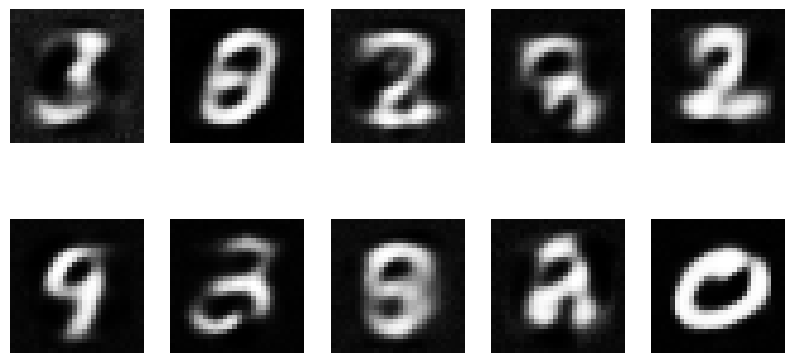

In [68]:
rng_key, sub_key = jax.random.split(rng_key)
plot_images(smivae74.sample(sub_key, 10)["x"], shape=(28, 28))

In [63]:
rng_key, sub_key = jax.random.split(rng_key)
X_test_sample = X_test[np.random.choice(X_test.shape[0], 10, replace=False)]
encoded = smivae74.encode_batch(X_test_sample, sub_key)

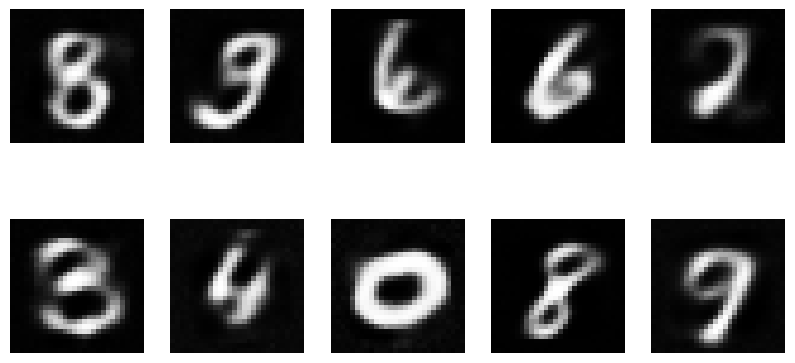

In [64]:


reconstructed = smivae74.decode_latent({"z0": encoded["z0"], "m": encoded["m"]}, sub_key, size_site="z0")["x"]
plot_images(reconstructed, shape=(28, 28))

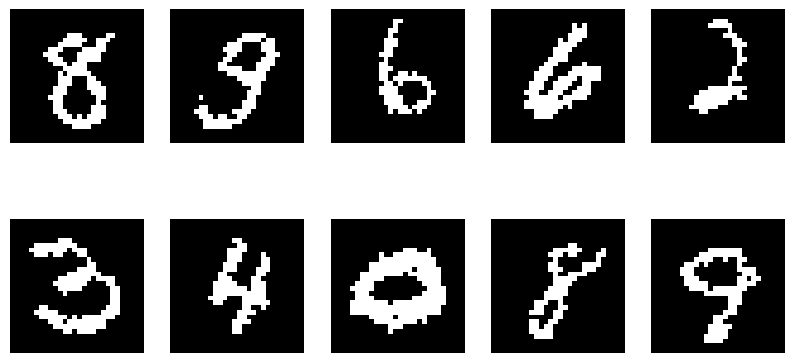

In [65]:

plot_images(X_test_sample, shape=(28, 28))